🔐 Dilithium-style Digital Signature Benchmark (using Ed25519 as proxy)

Average Signature + Verify time: 0.90 ms
Signature size: 64 bytes


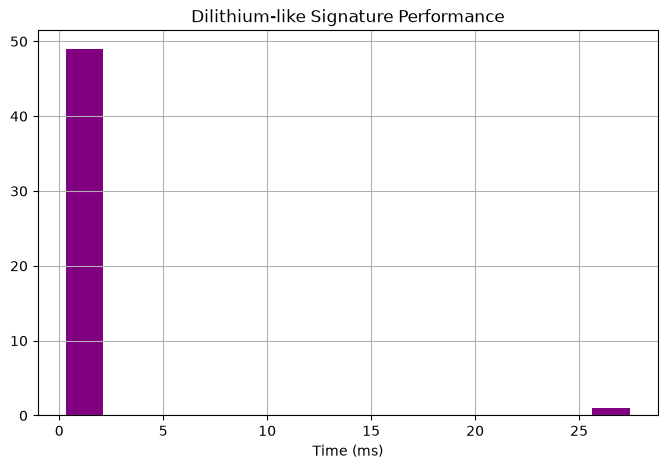

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import ed25519

print("🔐 Dilithium-style Digital Signature Benchmark (using Ed25519 as proxy)\n")

times = []
for i in range(50):
    start = time.time()
    
    # Key generation
    private_key = ed25519.Ed25519PrivateKey.generate()
    public_key = private_key.public_key()
    
    # Sign message
    message = b"Important quantum-safe document " + i.to_bytes(4, 'big')
    signature = private_key.sign(message)
    
    # Verify
    public_key.verify(signature, message)
    
    times.append(time.time() - start)

print(f"Average Signature + Verify time: {np.mean(times)*1000:.2f} ms")
print(f"Signature size: {len(signature)} bytes")

plt.figure(figsize=(8,5))
plt.hist(np.array(times)*1000, bins=15, color='purple')
plt.title("Dilithium-like Signature Performance")
plt.xlabel("Time (ms)")
plt.grid(True)
plt.show()